C:\Users\Dell\AppData\Local\Temp\ipykernel_20940\1136556776.py:5: DtypeWarning: Columns (22,23,24,25,26,27,28,29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  csv = pd.read_csv('lista_de_espera_sisu_2022_2.csv', sep='|', encoding='latin-1')


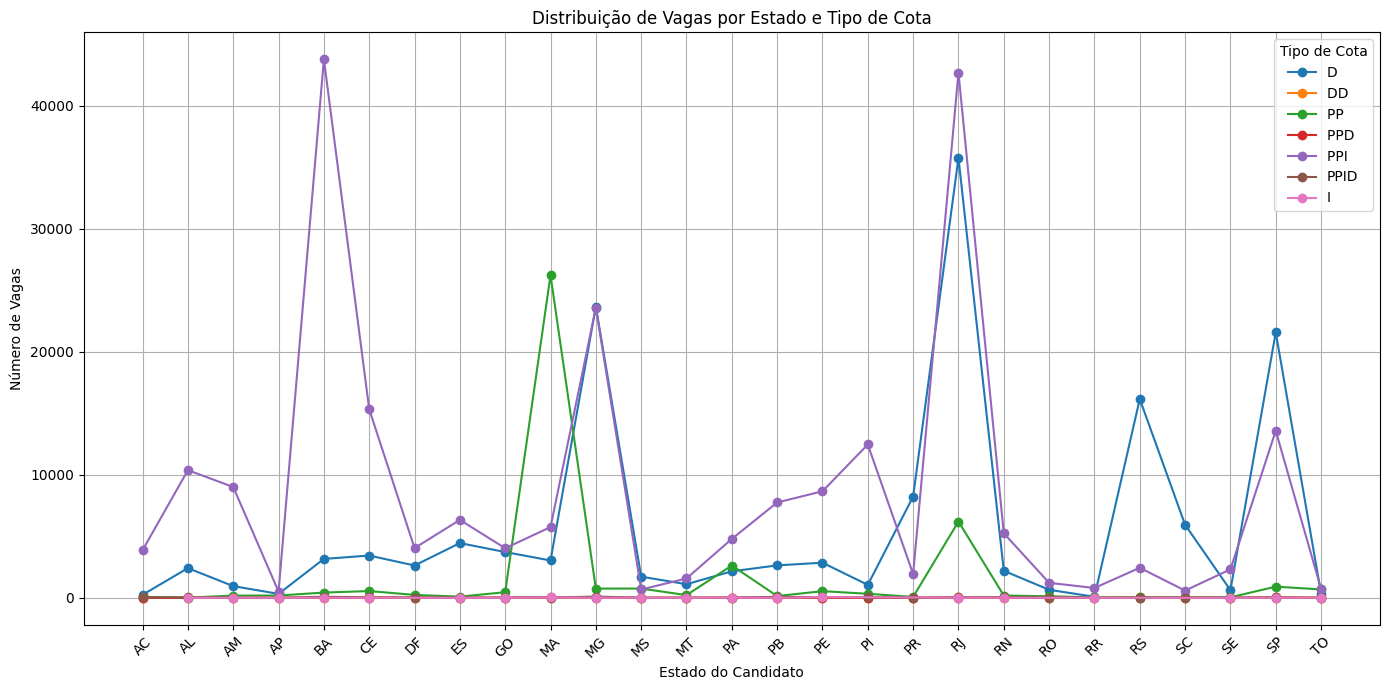

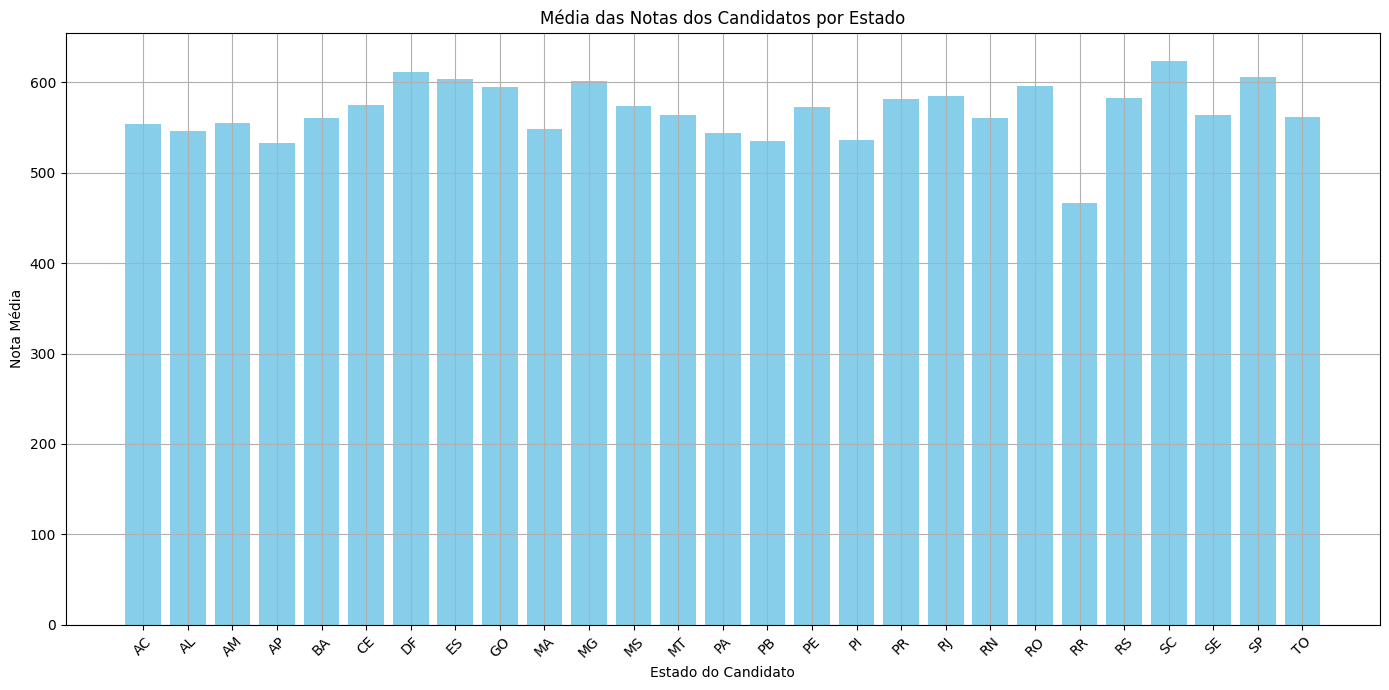

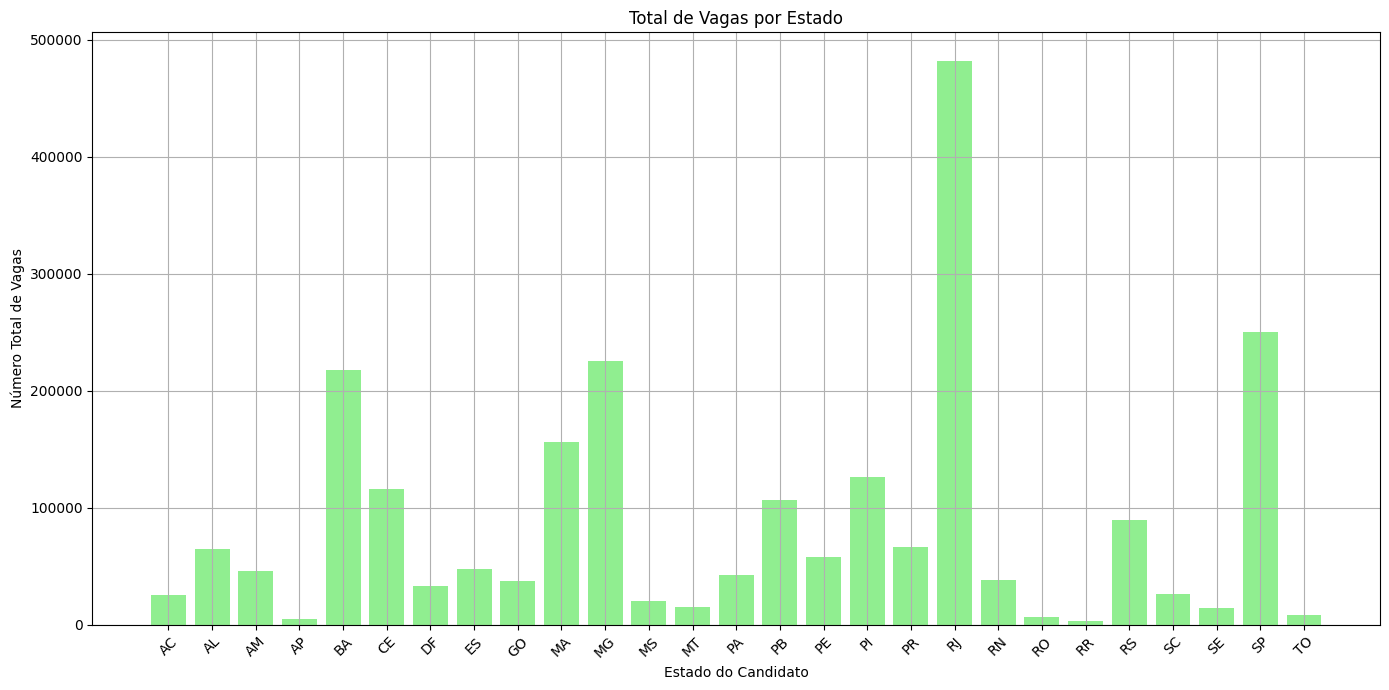

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar o arquivo CSV 
csv = pd.read_csv('lista_de_espera_sisu_2022_2.csv', sep='|', encoding='latin-1')

# Filtrar os dados
dados = csv[['UF_CANDIDATO', 'UF_IES', 'QT_VAGAS_CONCORRENCIA', 'NOTA_CANDIDATO', 'TP_COTA']]

# Limpar dados: remover linhas com valores ausentes ou inválidos
dados = dados.dropna(subset=['UF_CANDIDATO', 'UF_IES', 'QT_VAGAS_CONCORRENCIA', 'NOTA_CANDIDATO', 'TP_COTA'])

# Converter colunas para tipos apropriados
dados['QT_VAGAS_CONCORRENCIA'] = pd.to_numeric(dados['QT_VAGAS_CONCORRENCIA'], errors='coerce')
dados['NOTA_CANDIDATO'] = pd.to_numeric(dados['NOTA_CANDIDATO'], errors='coerce')

# Agrupar dados por UF do candidato e tipo de cota
agrupado_uf_cota = dados.groupby(['UF_CANDIDATO', 'TP_COTA']).agg({
    'QT_VAGAS_CONCORRENCIA': 'sum',
    'NOTA_CANDIDATO': 'mean'
}).reset_index()

# Agrupar dados por UF do candidato
total_vagas_uf = dados.groupby('UF_CANDIDATO')['QT_VAGAS_CONCORRENCIA'].sum().reset_index()
media_nota_uf = dados.groupby('UF_CANDIDATO')['NOTA_CANDIDATO'].mean().reset_index()

# Gráfico 1: Vagas por Estado e Tipo de Cota
plt.figure(figsize=(14, 7))
for tipo_cota in agrupado_uf_cota['TP_COTA'].unique():
    subset = agrupado_uf_cota[agrupado_uf_cota['TP_COTA'] == tipo_cota]
    plt.plot(subset['UF_CANDIDATO'], subset['QT_VAGAS_CONCORRENCIA'], marker='o', label=tipo_cota)

plt.xticks(rotation=45)
plt.title('Distribuição de Vagas por Estado e Tipo de Cota')
plt.xlabel('Estado do Candidato')
plt.ylabel('Número de Vagas')
plt.legend(title='Tipo de Cota')
plt.grid(True)
plt.tight_layout()
plt.savefig('vagas_por_estado_tipo_cota.png')
plt.show()

# Gráfico 2: Média das Notas dos Candidatos por Estado
plt.figure(figsize=(14, 7))
plt.bar(media_nota_uf['UF_CANDIDATO'], media_nota_uf['NOTA_CANDIDATO'], color='skyblue')
plt.xticks(rotation=45)
plt.title('Média das Notas dos Candidatos por Estado')
plt.xlabel('Estado do Candidato')
plt.ylabel('Nota Média')
plt.grid(True)
plt.tight_layout()
plt.savefig('media_notas_por_estado.png')
plt.show()

# Gráfico 3: Total de Vagas por Estado
plt.figure(figsize=(14, 7))
plt.bar(total_vagas_uf['UF_CANDIDATO'], total_vagas_uf['QT_VAGAS_CONCORRENCIA'], color='lightgreen')
plt.xticks(rotation=45)
plt.title('Total de Vagas por Estado')
plt.xlabel('Estado do Candidato')
plt.ylabel('Número Total de Vagas')
plt.grid(True)
plt.tight_layout()
plt.savefig('total_vagas_por_estado.png')
plt.show()
